In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Display plots inline
%matplotlib inline 

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# --- CONFIGURATION ---

# If you are on Kaggle, paths usually look like this:
# RAW_DIR = '/kaggle/input/uieb-dataset/raw-890'
# REF_DIR = '/kaggle/input/uieb-dataset/reference-890'

# If you are running locally, update this path:
RAW_DIR = r'dataset/raw'        
REF_DIR = r'dataset/reference' 

# Verify paths exist
if not os.path.exists(RAW_DIR):
    print(f"WARNING: Raw directory not found at {RAW_DIR}")
if not os.path.exists(REF_DIR):
    print(f"WARNING: Reference directory not found at {REF_DIR}")

print(f"Raw directory: {RAW_DIR}")
print(f"Reference directory: {REF_DIR}")

Raw directory: dataset/raw
Reference directory: dataset/reference


In [6]:
def calculate_metrics(img1, img2):
    """
    Calculates PSNR and SSIM between two images.
    Images must be the same size.
    """
    # Convert to grayscale for SSIM
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    # Calculate PSNR
    # data_range=255 is standard for 8-bit images
    psnr_val = psnr(img2, img1, data_range=255)
    
    # Calculate SSIM
    ssim_val = ssim(gray2, gray1, data_range=255)
    
    return psnr_val, ssim_val

In [7]:
# --- DEFINE YOUR ENHANCEMENT FUNCTION HERE ---
def enhance_image(image):
    """
    Input:  OpenCV image (BGR)
    Output: Enhanced OpenCV image (BGR)
    
    Replace the code below with your actual model or algorithm.
    """
    # Example: Simple CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # This is a common baseline for underwater images.
    
    # 1. Split channels
    b, g, r = cv2.split(image)
    
    # 2. Create CLAHE object
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    # 3. Apply to each channel
    b_enhanced = clahe.apply(b)
    g_enhanced = clahe.apply(g)
    r_enhanced = clahe.apply(r)
    
    # 4. Merge
    enhanced_img = cv2.merge((b_enhanced, g_enhanced, r_enhanced))
    
    return enhanced_img  # Return the processed image

# ---------------------------------------------

# Lists to store results
psnr_scores = []
ssim_scores = []
processed_count = 0

# Get list of files
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp')
raw_files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith(valid_exts)]
raw_files.sort()

print(f"Found {len(raw_files)} images.")
print("-" * 65)
print(f"{'Image Name':<25} | {'PSNR (dB)':<12} | {'SSIM':<12}")
print("-" * 65)

for filename in raw_files:
    # 1. Construct paths
    raw_path = os.path.join(RAW_DIR, filename)
    ref_path = os.path.join(REF_DIR, filename)
    
    # 2. Check for reference existence
    if not os.path.exists(ref_path):
        # Try alternate extension (e.g. raw is .jpg, ref is .png)
        base, _ = os.path.splitext(filename)
        ref_path_png = os.path.join(REF_DIR, base + ".png")
        if os.path.exists(ref_path_png):
            ref_path = ref_path_png
        else:
            continue # Skip if no reference found

    # 3. Load Images
    img_raw = cv2.imread(raw_path)
    img_ref = cv2.imread(ref_path)
    
    if img_raw is None or img_ref is None: 
        continue
        
    # 4. Apply Enhancement (The "Processing" Step)
    img_enhanced = enhance_image(img_raw)
    
    # 5. Resize Reference if dimensions don't match
    if img_enhanced.shape != img_ref.shape:
        img_ref = cv2.resize(img_ref, (img_enhanced.shape[1], img_enhanced.shape[0]))

    # 6. Calculate Metrics (Enhanced vs Reference)
    try:
        curr_psnr, curr_ssim = calculate_metrics(img_enhanced, img_ref)
        
        psnr_scores.append(curr_psnr)
        ssim_scores.append(curr_ssim)
        processed_count += 1
        
        if processed_count % 50 == 0:
            print(f"{filename:<25} | {curr_psnr:.2f}         | {curr_ssim:.4f}")
            
    except Exception as e:
        print(f"Error on {filename}: {e}")

print("-" * 65)
print("Processing Complete.")

Found 890 images.
-----------------------------------------------------------------
Image Name                | PSNR (dB)    | SSIM        
-----------------------------------------------------------------
137_img_.png              | 15.10         | 0.8738
170_img_.png              | 19.09         | 0.9848
215_img_.png              | 18.02         | 0.9099
2677.png                  | 22.67         | 0.9772
311_img_.png              | 18.08         | 0.8743
367_img_.png              | 15.11         | 0.8841
417_img_.png              | 16.82         | 0.9382
468_img_.png              | 18.52         | 0.8980
517_img_.png              | 23.10         | 0.9754
567_img_.png              | 19.81         | 0.9768
608_img_.png              | 15.18         | 0.7555
655_img_.png              | 14.84         | 0.9354
704_img_.png              | 17.52         | 0.9789
753_img_.png              | 14.78         | 0.6999
798_img_.png              | 20.94         | 0.9668
846_img_.png              | 2


 FINAL RESULTS (Total Images: 890)
 AVERAGE PSNR: 18.2282 dB
 AVERAGE SSIM: 0.9030


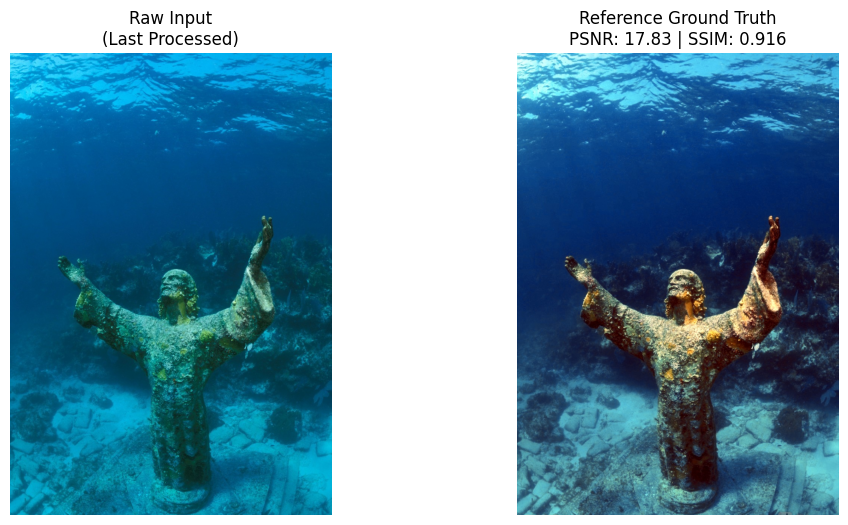

In [8]:
if processed_count > 0:
    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)

    print("\n" + "="*40)
    print(f" FINAL RESULTS (Total Images: {processed_count})")
    print("="*40)
    print(f" AVERAGE PSNR: {avg_psnr:.4f} dB")
    print(f" AVERAGE SSIM: {avg_ssim:.4f}")
    print("="*40)
    
    # --- VISUALIZATION OF LAST PROCESSED IMAGE ---
    # Convert BGR to RGB for Matplotlib
    img_raw_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_ref_rgb = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title(f"Raw Input\n(Last Processed)")
    plt.imshow(img_raw_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Reference Ground Truth\nPSNR: {psnr_scores[-1]:.2f} | SSIM: {ssim_scores[-1]:.3f}")
    plt.imshow(img_ref_rgb)
    plt.axis('off')
    
    plt.show()

else:
    print("No images were processed. Please check your RAW_DIR and REF_DIR paths.")

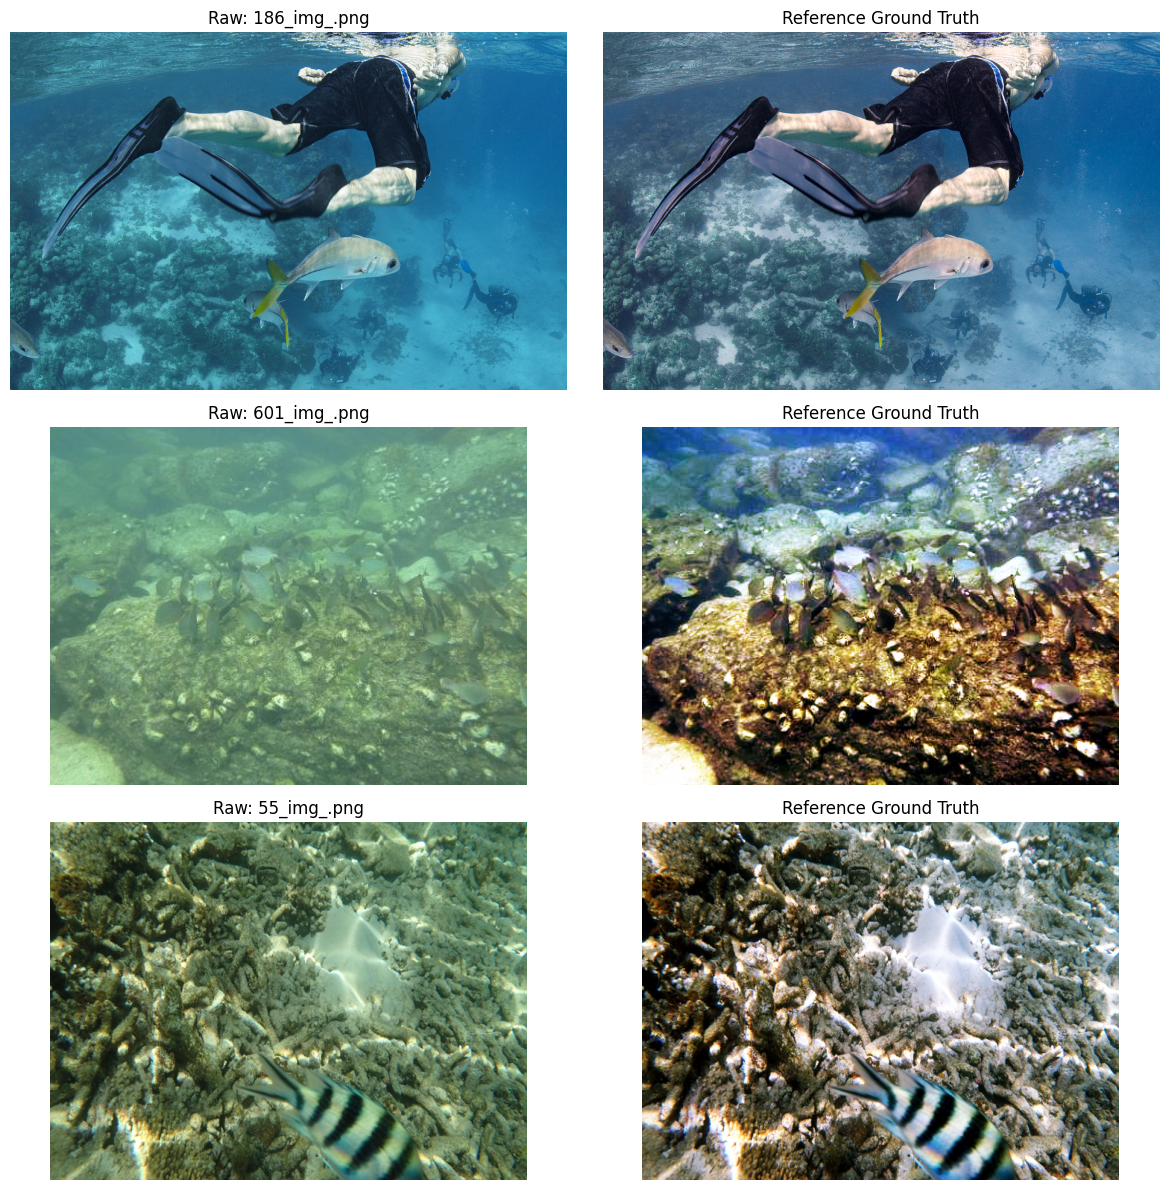

In [10]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# Update these paths if needed
RAW_DIR = 'dataset/raw'
REF_DIR = 'dataset/reference'

def visualize_random_pairs(num_samples=3):
    # Get all valid image files
    valid_exts = ('.png', '.jpg', '.jpeg')
    all_files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith(valid_exts)]
    
    # Pick random samples
    samples = random.sample(all_files, num_samples)
    
    plt.figure(figsize=(12, 4 * num_samples))
    
    for i, filename in enumerate(samples):
        # Construct paths
        raw_path = os.path.join(RAW_DIR, filename)
        ref_path = os.path.join(REF_DIR, filename)
        
        # Handle missing reference (try .png if .jpg)
        if not os.path.exists(ref_path):
             ref_path = os.path.join(REF_DIR, os.path.splitext(filename)[0] + ".png")
        
        # Load and convert BGR to RGB
        img_raw = cv2.cvtColor(cv2.imread(raw_path), cv2.COLOR_BGR2RGB)
        if os.path.exists(ref_path):
            img_ref = cv2.cvtColor(cv2.imread(ref_path), cv2.COLOR_BGR2RGB)
        else:
            img_ref = np.zeros_like(img_raw) # Black if missing

        # Plot Raw
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(img_raw)
        plt.title(f"Raw: {filename}")
        plt.axis('off')
        
        # Plot Reference
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(img_ref)
        plt.title(f"Reference Ground Truth")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the function
visualize_random_pairs(3)

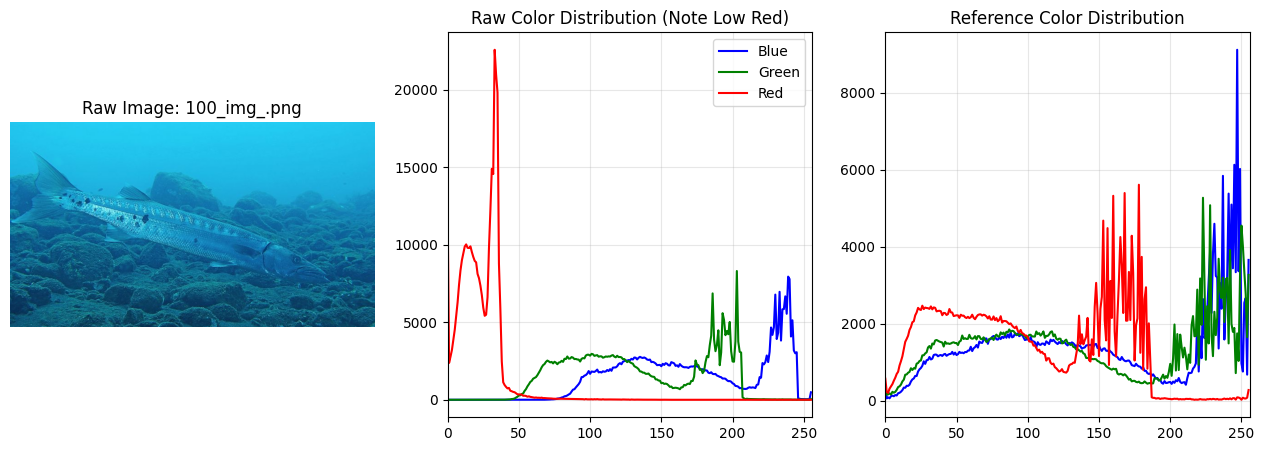

In [11]:
def plot_histogram_comparison(filename):
    raw_path = os.path.join(RAW_DIR, filename)
    ref_path = os.path.join(REF_DIR, filename)
    
    # Handle extension mismatch if necessary
    if not os.path.exists(ref_path):
        ref_path = os.path.join(REF_DIR, os.path.splitext(filename)[0] + ".png")

    img_raw = cv2.imread(raw_path)
    img_ref = cv2.imread(ref_path)
    
    colors = ('b', 'g', 'r')
    labels = ('Blue', 'Green', 'Red')
    
    plt.figure(figsize=(16, 5))
    
    # 1. Display the Image Pair
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw Image: {filename}")
    plt.axis('off')
    
    # 2. Raw Histogram
    plt.subplot(1, 3, 2)
    plt.title("Raw Color Distribution (Note Low Red)")
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img_raw], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, label=labels[i])
    plt.xlim([0, 256])
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Reference Histogram
    plt.subplot(1, 3, 3)
    plt.title("Reference Color Distribution")
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img_ref], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)
    
    plt.show()

# Pick the first image in the folder to test
first_image = [f for f in os.listdir(RAW_DIR) if f.endswith(('.jpg', '.png'))][0]
plot_histogram_comparison(first_image)

Calculating average channel intensity for 100 images...


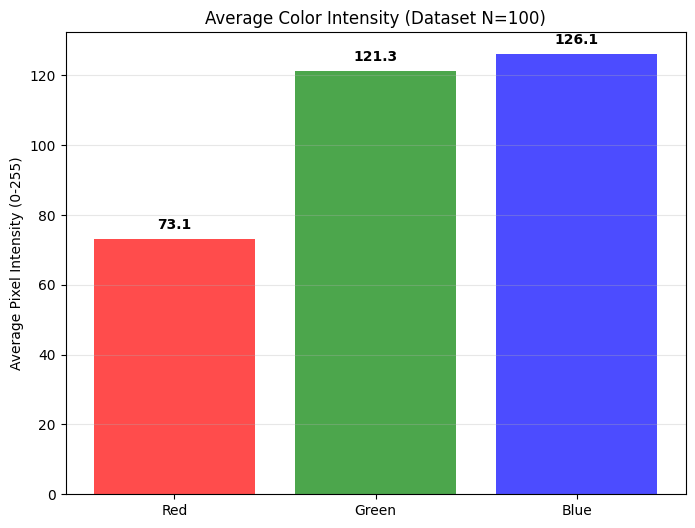

In [12]:
import numpy as np

def visualize_average_channels(num_images=50):
    files = [f for f in os.listdir(RAW_DIR) if f.endswith(('.jpg', '.png'))]
    # Limit to num_images to save time
    files = files[:num_images]
    
    r_means, g_means, b_means = [], [], []
    
    print(f"Calculating average channel intensity for {len(files)} images...")
    
    for f in files:
        img = cv2.imread(os.path.join(RAW_DIR, f))
        if img is None: continue
        
        # OpenCV loads as BGR
        b_mean = np.mean(img[:, :, 0])
        g_mean = np.mean(img[:, :, 1])
        r_mean = np.mean(img[:, :, 2])
        
        b_means.append(b_mean)
        g_means.append(g_mean)
        r_means.append(r_mean)
        
    # Plotting
    channels = ['Red', 'Green', 'Blue']
    means = [np.mean(r_means), np.mean(g_means), np.mean(b_means)]
    colors = ['red', 'green', 'blue']
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(channels, means, color=colors, alpha=0.7)
    
    plt.title(f"Average Color Intensity (Dataset N={len(files)})")
    plt.ylabel("Average Pixel Intensity (0-255)")
    plt.grid(axis='y', alpha=0.3)
    
    # Add text labels on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}", ha='center', va='bottom', fontweight='bold')
        
    plt.show()

visualize_average_channels(100)

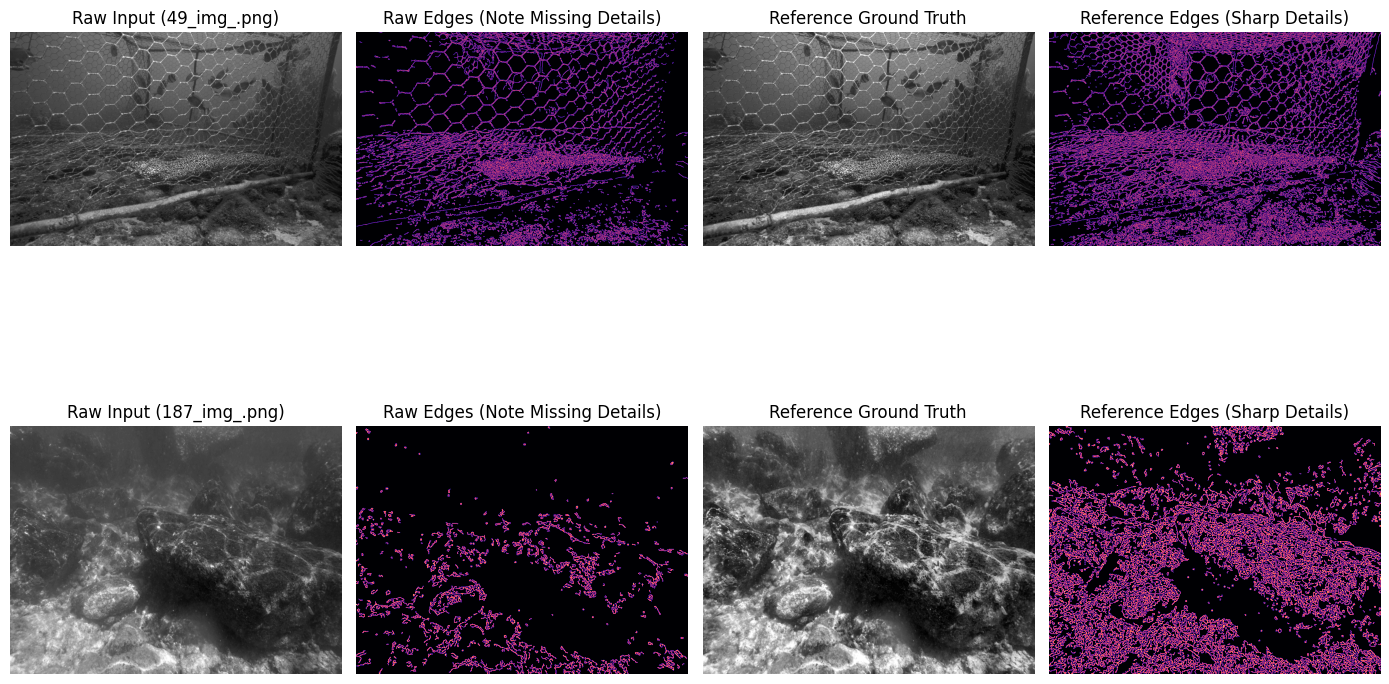

In [13]:
def visualize_edge_loss(num_samples=2):
    # Get random files
    all_files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith(('.png', '.jpg'))]
    samples = random.sample(all_files, num_samples)
    
    plt.figure(figsize=(14, 5 * num_samples))
    
    for i, filename in enumerate(samples):
        # Load paths
        raw_path = os.path.join(RAW_DIR, filename)
        ref_path = os.path.join(REF_DIR, filename)
        if not os.path.exists(ref_path):
             ref_path = os.path.join(REF_DIR, os.path.splitext(filename)[0] + ".png")
        
        # Load as Grayscale for Edge Detection
        img_raw_gray = cv2.imread(raw_path, 0)
        img_ref_gray = cv2.imread(ref_path, 0)
        
        if img_raw_gray is None or img_ref_gray is None: continue
            
        # Apply Canny Edge Detection
        # Thresholds (100, 200) are standard; you can tweak them
        edges_raw = cv2.Canny(img_raw_gray, 100, 200)
        edges_ref = cv2.Canny(img_ref_gray, 100, 200)
        
        # Plotting
        # Row 1: Raw Image & Edges
        plt.subplot(num_samples, 4, 4*i + 1)
        plt.imshow(img_raw_gray, cmap='gray')
        plt.title(f"Raw Input ({filename})")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, 4*i + 2)
        plt.imshow(edges_raw, cmap='magma') # Magma makes edges pop
        plt.title("Raw Edges (Note Missing Details)")
        plt.axis('off')
        
        # Row 2: Reference Image & Edges
        plt.subplot(num_samples, 4, 4*i + 3)
        plt.imshow(img_ref_gray, cmap='gray')
        plt.title("Reference Ground Truth")
        plt.axis('off')
        
        plt.subplot(num_samples, 4, 4*i + 4)
        plt.imshow(edges_ref, cmap='magma')
        plt.title("Reference Edges (Sharp Details)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_edge_loss(2)

Sampling pixels from 50 images...


C:\Users\himan\AppData\Local\Temp\ipykernel_26332\3993217724.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Channel', y='Intensity', data=pixel_data, palette=['blue', 'green', 'red'])


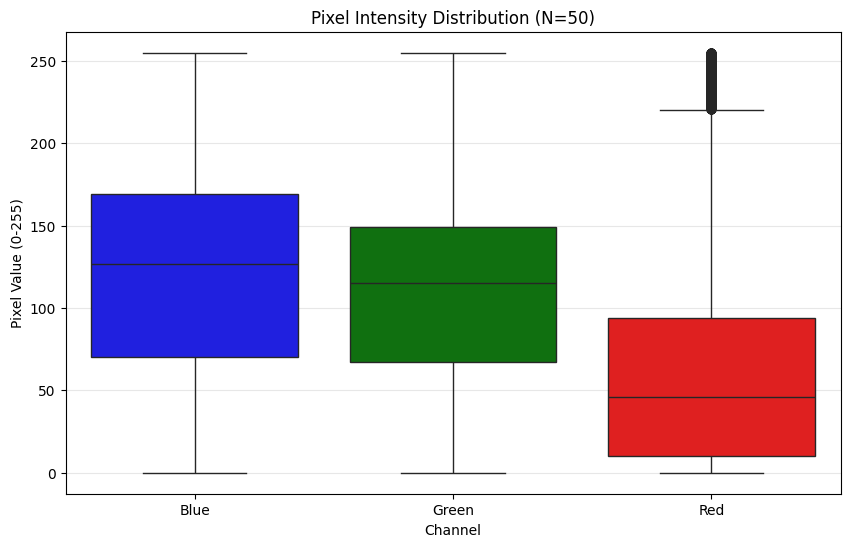

In [15]:
import seaborn as sns # Easier for boxplots

def plot_channel_distribution(num_images=50):
    files = [f for f in os.listdir(RAW_DIR) if f.endswith(('.jpg', '.png'))][:num_images]
    
    pixel_data = {'Channel': [], 'Intensity': []}
    
    print(f"Sampling pixels from {num_images} images...")
    
    for f in files:
        img = cv2.imread(os.path.join(RAW_DIR, f))
        if img is None: continue
        
        # Downsample image to speed up plotting (1 pixel every 100)
        # Otherwise we have millions of points
        b_pixels = img[::10, ::10, 0].flatten()
        g_pixels = img[::10, ::10, 1].flatten()
        r_pixels = img[::10, ::10, 2].flatten()
        
        # Add to list
        pixel_data['Channel'].extend(['Blue'] * len(b_pixels))
        pixel_data['Intensity'].extend(b_pixels)
        
        pixel_data['Channel'].extend(['Green'] * len(g_pixels))
        pixel_data['Intensity'].extend(g_pixels)
        
        pixel_data['Channel'].extend(['Red'] * len(r_pixels))
        pixel_data['Intensity'].extend(r_pixels)
        
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Channel', y='Intensity', data=pixel_data, palette=['blue', 'green', 'red'])
    
    plt.title(f"Pixel Intensity Distribution (N={num_images})")
    plt.ylabel("Pixel Value (0-255)")
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

# Run it
plot_channel_distribution(50)

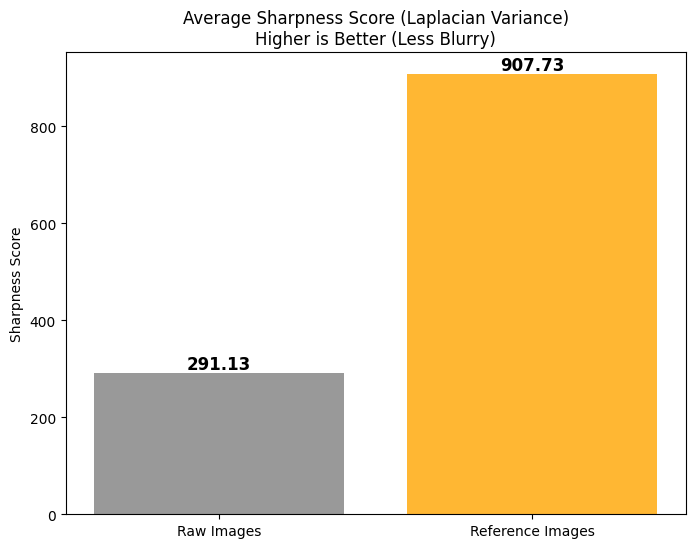

Raw Avg: 291.13 | Ref Avg: 907.73
Interpretation: Reference images are 3.1x sharper than raw images.


In [16]:
def variance_of_laplacian(image):
    # Compute the Laplacian of the image and then return the focus
    # measure, which is simply the variance of the Laplacian
    return cv2.Laplacian(image, cv2.CV_64F).var()

def calculate_blur_stats(num_images=100):
    files = [f for f in os.listdir(RAW_DIR) if f.endswith(('.jpg', '.png'))][:num_images]
    
    raw_scores = []
    ref_scores = []
    
    for f in files:
        raw_path = os.path.join(RAW_DIR, f)
        ref_path = os.path.join(REF_DIR, f)
        if not os.path.exists(ref_path):
             ref_path = os.path.join(REF_DIR, os.path.splitext(f)[0] + ".png")
        
        img_raw = cv2.imread(raw_path, 0) # Load as Gray
        img_ref = cv2.imread(ref_path, 0)
        
        if img_raw is not None and img_ref is not None:
            raw_scores.append(variance_of_laplacian(img_raw))
            ref_scores.append(variance_of_laplacian(img_ref))
            
    # Plotting results
    plt.figure(figsize=(8, 6))
    
    # Create simple bar chart of averages
    labels = ['Raw Images', 'Reference Images']
    means = [np.mean(raw_scores), np.mean(ref_scores)]
    
    bars = plt.bar(labels, means, color=['gray', 'orange'], alpha=0.8)
    
    plt.title(f"Average Sharpness Score (Laplacian Variance)\nHigher is Better (Less Blurry)")
    plt.ylabel("Sharpness Score")
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
                
    plt.show()
    print(f"Raw Avg: {means[0]:.2f} | Ref Avg: {means[1]:.2f}")
    print(f"Interpretation: Reference images are {means[1]/means[0]:.1f}x sharper than raw images.")

calculate_blur_stats(100)

In [18]:
import numpy as np
from PIL import Image, ImageFilter, ImageOps
import matplotlib.pyplot as plt
import cv2
import os

# --- ALGORITHMS ---

def compensate_RB(image, flag):
    # Split channels
    imager, imageg, imageb = image.split()
    
    # Get ranges
    minR, maxR = imager.getextrema()
    minG, maxG = imageg.getextrema()
    minB, maxB = imageb.getextrema()
    
    # Convert to arrays
    imageR = np.array(imager, np.float64)
    imageG = np.array(imageg, np.float64)
    imageB = np.array(imageb, np.float64)
    
    x, y = image.size
    
    # Normalize
    imageR = (imageR - minR) / (maxR - minR)
    imageG = (imageG - minG) / (maxG - minG)
    imageB = (imageB - minB) / (maxB - minB)
    
    meanR = np.mean(imageR)
    meanG = np.mean(imageG)
    meanB = np.mean(imageB)
    
    # Compensate Logic
    if flag == 1:
        for i in range(y):
            for j in range(x):
                imageR[i][j] = int((imageR[i][j] + (meanG - meanR) * (1 - imageR[i][j]) * imageG[i][j]) * maxR)
        for i in range(y):
            for j in range(x):
                imageB[i][j] = int(imageB[i][j] * maxB)
                imageG[i][j] = int(imageG[i][j] * maxG)
            
    compensateIm = np.zeros((y, x, 3), dtype="uint8")
    compensateIm[:, :, 0] = imageR
    compensateIm[:, :, 1] = imageG
    compensateIm[:, :, 2] = imageB
    
    return Image.fromarray(compensateIm)

def gray_world(image):
    imager, imageg, imageb = image.split()
    imagegray = image.convert('L')
    
    imageR = np.array(imager, np.float64)
    imageG = np.array(imageg, np.float64)
    imageB = np.array(imageb, np.float64)
    imageGray = np.array(imagegray, np.float64)
    
    x, y = image.size
    meanR, meanG, meanB = np.mean(imageR), np.mean(imageG), np.mean(imageB)
    meanGray = np.mean(imageGray)
    
    imageR = (imageR * (meanGray / meanR)).astype(np.uint8)
    imageG = (imageG * (meanGray / meanG)).astype(np.uint8)
    imageB = (imageB * (meanGray / meanB)).astype(np.uint8)
    
    whitebalancedIm = np.zeros((y, x, 3), dtype="uint8")
    whitebalancedIm[:, :, 0] = imageR
    whitebalancedIm[:, :, 1] = imageG
    whitebalancedIm[:, :, 2] = imageB
    
    return Image.fromarray(whitebalancedIm)

def sharpen_image(wbimage):
    smoothed_image = wbimage.filter(ImageFilter.GaussianBlur)
    imager, imageg, imageb = wbimage.split()
    smoothedr, smoothedg, smoothedb = smoothed_image.split()
    
    imageR = np.array(imager, np.float64)
    imageG = np.array(imageg, np.float64)
    imageB = np.array(imageb, np.float64)
    smoothedR = np.array(smoothedr, np.float64)
    smoothedG = np.array(smoothedg, np.float64)
    smoothedB = np.array(smoothedb, np.float64)
    
    x, y = wbimage.size
    imageR = np.clip(2 * imageR - smoothedR, 0, 255)
    imageG = np.clip(2 * imageG - smoothedG, 0, 255)
    imageB = np.clip(2 * imageB - smoothedB, 0, 255)
    
    sharpenIm = np.zeros((y, x, 3), dtype="uint8")        
    sharpenIm[:, :, 0] = imageR
    sharpenIm[:, :, 1] = imageG
    sharpenIm[:, :, 2] = imageB
    
    return Image.fromarray(sharpenIm)

def hsv_global_equalization(image):
    hsvimage = image.convert('HSV')
    Hue, Saturation, Value = hsvimage.split()
    equalizedValue = ImageOps.equalize(Value, mask=None)
    
    x, y = image.size
    equalizedIm = np.zeros((y, x, 3), dtype="uint8")
    equalizedIm[:, :, 0] = np.array(Hue)
    equalizedIm[:, :, 1] = np.array(Saturation)
    equalizedIm[:, :, 2] = np.array(equalizedValue)
    
    hsvimage = Image.fromarray(equalizedIm, 'HSV')
    return hsvimage.convert('RGB')

def pca_fusion(image1, image2):
    image1r, image1g, image1b = image1.split()
    image2r, image2g, image2b = image2.split()
    
    image1R = np.array(image1r, np.float64).flatten()
    image1G = np.array(image1g, np.float64).flatten()
    image1B = np.array(image1b, np.float64).flatten()
    image2R = np.array(image2r, np.float64).flatten()
    image2G = np.array(image2g, np.float64).flatten()
    image2B = np.array(image2b, np.float64).flatten()
    
    mean1R, mean1G, mean1B = np.mean(image1R), np.mean(image1G), np.mean(image1B)
    mean2R, mean2G, mean2B = np.mean(image2R), np.mean(image2G), np.mean(image2B)
    
    imageR = np.array((image1R - mean1R, image2R - mean2R))
    imageG = np.array((image1G - mean1G, image2G - mean2G))
    imageB = np.array((image1B - mean1B, image2B - mean2B))
    
    def get_weights(cov_matrix):
        val, vec = np.linalg.eig(cov_matrix)
        if val[0] >= val[1]:
            return vec[:, 0] / sum(vec[:, 0])
        else:
            return vec[:, 1] / sum(vec[:, 1])

    coefR = get_weights(np.cov(imageR))
    coefG = get_weights(np.cov(imageG))
    coefB = get_weights(np.cov(imageB))
    
    img1_arr = np.array(image1, np.float64)
    img2_arr = np.array(image2, np.float64)
    fusedIm = np.zeros(img1_arr.shape, dtype="uint8")
    
    fusedIm[:,:,0] = coefR[0]*img1_arr[:,:,0] + coefR[1]*img2_arr[:,:,0]
    fusedIm[:,:,1] = coefG[0]*img1_arr[:,:,1] + coefG[1]*img2_arr[:,:,1]
    fusedIm[:,:,2] = coefB[0]*img1_arr[:,:,2] + coefB[1]*img2_arr[:,:,2]
    
    return Image.fromarray(fusedIm)

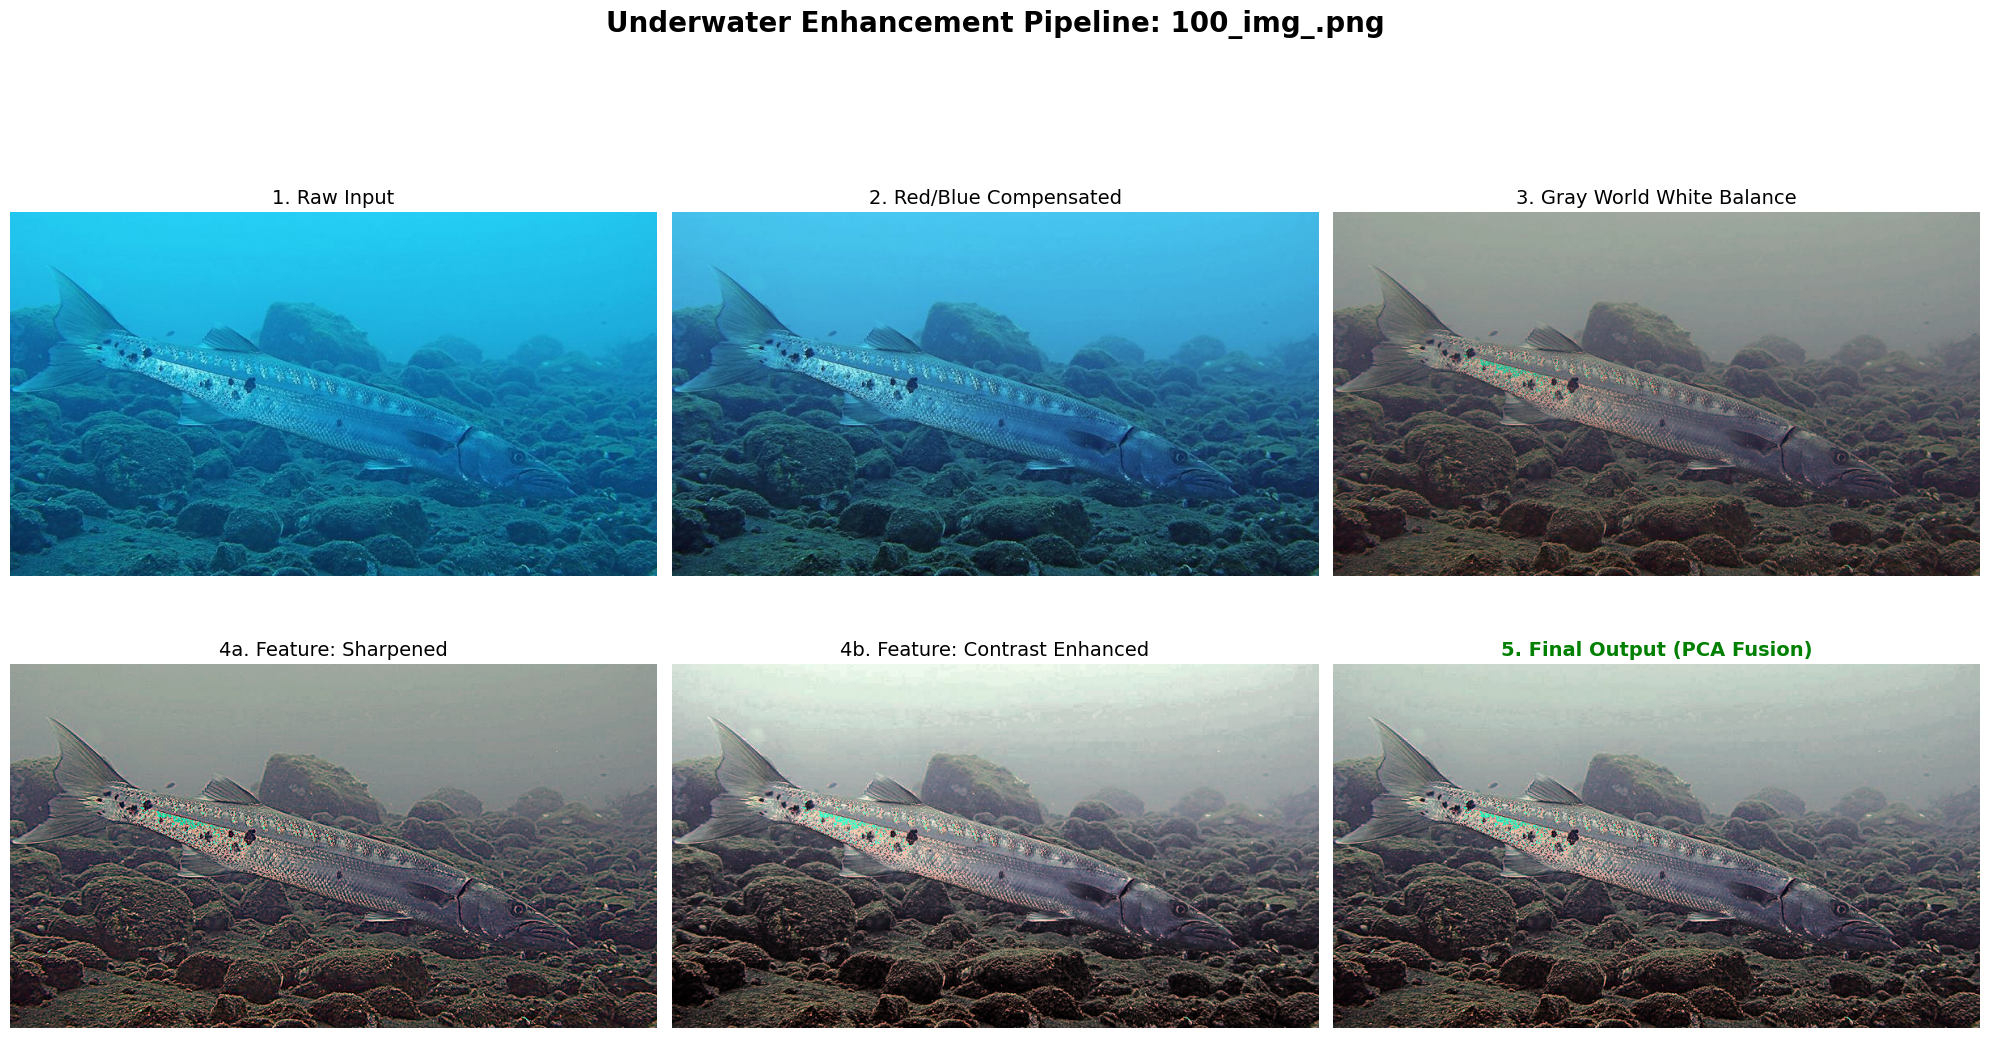

In [20]:
def visualize_full_pipeline(filename=None):
    # 1. Select Image
    if filename is None:
        # Pick random if not specified
        valid_exts = ('.png', '.jpg')
        files = [f for f in os.listdir(RAW_DIR) if f.lower().endswith(valid_exts)]
        if not files: return
        filename = files[0] # Or random.choice(files)
    
    path = os.path.join(RAW_DIR, filename)
    
    # Load using PIL for processing
    original_pil = Image.open(path).convert('RGB')
    
    # --- PROCESS ---
    # Step 1: RB Compensation
    step1_rb = compensate_RB(original_pil, flag=1)
    
    # Step 2: White Balance
    step2_wb = gray_world(step1_rb)
    
    # Step 3: Feature Inputs
    step3_sharp = sharpen_image(step2_wb)
    step3_cont = hsv_global_equalization(step2_wb)
    
    # Step 4: Fusion
    step4_final = pca_fusion(step3_sharp, step3_cont)
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f"Underwater Enhancement Pipeline: {filename}", fontsize=20, weight='bold')
    
    # Row 1
    axes[0,0].imshow(original_pil)
    axes[0,0].set_title("1. Raw Input", fontsize=14)
    axes[0,0].axis('off')
    
    axes[0,1].imshow(step1_rb)
    axes[0,1].set_title("2. Red/Blue Compensated", fontsize=14)
    axes[0,1].axis('off')
    
    axes[0,2].imshow(step2_wb)
    axes[0,2].set_title("3. Gray World White Balance", fontsize=14)
    axes[0,2].axis('off')
    
    # Row 2
    axes[1,0].imshow(step3_sharp)
    axes[1,0].set_title("4a. Feature: Sharpened", fontsize=14)
    axes[1,0].axis('off')
    
    axes[1,1].imshow(step3_cont)
    axes[1,1].set_title("4b. Feature: Contrast Enhanced", fontsize=14)
    axes[1,1].axis('off')
    
    axes[1,2].imshow(step4_final)
    axes[1,2].set_title("5. Final Output (PCA Fusion)", fontsize=14, color='green', weight='bold')
    axes[1,2].axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the visualization
visualize_full_pipeline()

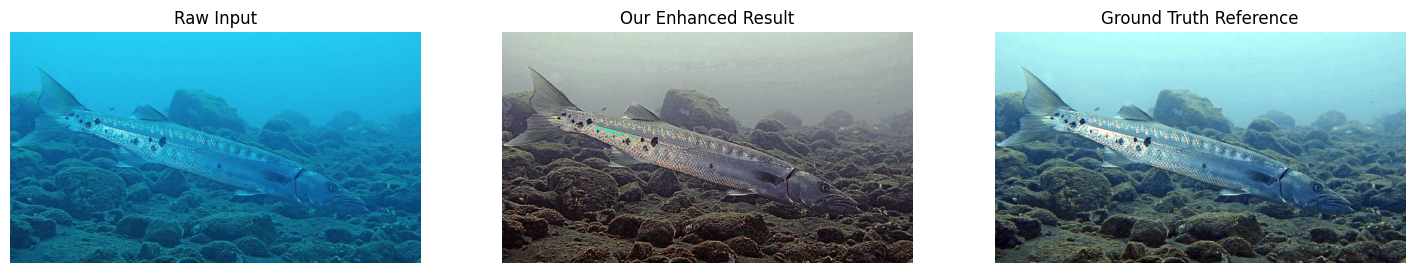

In [21]:
def compare_results(filename=None):
    if filename is None:
        files = [f for f in os.listdir(RAW_DIR) if f.endswith(('.jpg','.png'))]
        filename = files[0]
        
    # Paths
    raw_path = os.path.join(RAW_DIR, filename)
    ref_path = os.path.join(REF_DIR, filename)
    if not os.path.exists(ref_path):
        ref_path = os.path.join(REF_DIR, os.path.splitext(filename)[0] + ".png")
        
    # Process
    img_pil = Image.open(raw_path).convert('RGB')
    
    # Run full pipeline (simplified call)
    temp = compensate_RB(img_pil, 1)
    temp = gray_world(temp)
    res = pca_fusion(sharpen_image(temp), hsv_global_equalization(temp))
    
    # Load Ref
    if os.path.exists(ref_path):
        ref_pil = Image.open(ref_path).convert('RGB')
    else:
        ref_pil = Image.new('RGB', img_pil.size, (0,0,0))
        
    # Plot
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1,3,1)
    plt.imshow(img_pil)
    plt.title("Raw Input")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(res)
    plt.title("Our Enhanced Result")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(ref_pil)
    plt.title("Ground Truth Reference")
    plt.axis('off')
    
    plt.show()

compare_results()